In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import nltk
from nltk.corpus import stopwords

In [2]:
file = 'reddit_ukraine.csv'

In [3]:
df = pd.read_csv(file)

C:\Users\Мілана\AppData\Local\Temp\ipykernel_6716\2131829638.py:1: DtypeWarning: Columns (0,1,5,11,12,15,17,18,23,24,26,27,28,29,30,31,44,46,50,52,54,63,64,83,90,91,97,100,101,103,107,109,116,118,119,120,122,123,125,126) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


## 1. General metrics:

In [4]:
total_size_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Total data size: {total_size_mb:.2f} MB")

Total data size: 2052.23 MB


In [5]:
num_rows = len(df)
print(f"Number of rows (records): {num_rows:,}")

Number of rows (records): 349,430


In [6]:
print("DataFrame columns:")
print(df.columns.tolist())

DataFrame columns:
['allow_live_comments', 'archived', 'author', 'author_created_utc', 'author_flair_background_color', 'author_flair_css_class', 'author_flair_template_id', 'author_flair_text', 'author_flair_text_color', 'awarders', 'banned_by', 'can_gild', 'can_mod_post', 'category', 'content_categories', 'contest_mode', 'created_utc', 'discussion_type', 'distinguished', 'domain', 'edited', 'gilded', 'gildings', 'hidden', 'hide_score', 'id', 'is_created_from_ads_ui', 'is_crosspostable', 'is_meta', 'is_original_content', 'is_reddit_media_domain', 'is_robot_indexable', 'is_self', 'is_video', 'link_flair_background_color', 'link_flair_css_class', 'link_flair_richtext', 'link_flair_template_id', 'link_flair_text', 'link_flair_text_color', 'link_flair_type', 'locked', 'media', 'media_embed', 'media_only', 'name', 'no_follow', 'num_comments', 'num_crossposts', 'over_18', 'parent_whitelist_status', 'permalink', 'pinned', 'pwls', 'quarantine', 'removed_by', 'removed_by_category', 'retrieved_

In [7]:
df.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349430 entries, 0 to 349429
Data columns (total 127 columns):
 #    Column                         Dtype  
---   ------                         -----  
 0    allow_live_comments            object 
 1    archived                       object 
 2    author                         object 
 3    author_created_utc             float64
 4    author_flair_background_color  object 
 5    author_flair_css_class         object 
 6    author_flair_template_id       object 
 7    author_flair_text              object 
 8    author_flair_text_color        object 
 9    awarders                       object 
 10   banned_by                      float64
 11   can_gild                       object 
 12   can_mod_post                   object 
 13   category                       float64
 14   content_categories             float64
 15   contest_mode                   object 
 16   created_utc                    float64
 17   discussion_type            

## 2. Cleaning the data:

As we will observe, the raw dataset will contain over 100 columns, most of which will be Reddit-specific metadata that will have no predictive value for our task. We will keep only the columns that will be directly useful for modeling, analysis, or data cleaning:

* `created_utc` - the timestamp of each post. This will be the most important column since it will let us align Reddit data with air raid records and weather data by time.
  
* `subreddit_id` - will be used as a filter during data cleaning to ensure no posts from unintended communities will have slipped into the dataset.

* `title` and `selftext` - the actual text of the post. We will use these for NLP processing, specifically for building TF-IDF vectors alongside ISW report data.

* `score`, `num_comments`, `upvote_ratio` - measures of how much attention a post will have received. These will be used in feature engineering to detect unusual spikes in social media activity, which may correlate with real-world events.

* `link_flair_text` - the category tag assigned to a post. This will be useful during EDA to filter out off-topic content and focus on war-related posts.

* `is_self` and `is_video` - will be used to identify the type of post. Posts with media-only content and no text will be removed, as they will provide no useful signal for NLP tasks. `is_video` additionally will help assess post credibility, since video evidence may indicate a more verifiable event.

* `edited` - will indicate whether and when a post was modified. Posts edited more than one day after publication will be treated with caution or excluded, as late edits may distort the original signal.

* `author` - will be retained for exploratory analysis to identify the most active and influential contributors or bots in the dataset.

* `stickied` - stickied posts will typically be moderator announcements rather than organic community content, so this column will be needed to filter them out during preprocessing.


The `subreddit` column will be initially considered but excluded — since the entire dataset will come from a single community (r/ukraine), it will carry a constant value and will provide no useful information. Everything else — thumbnails, flair CSS classes, award metadata, and similar fields — will be dropped as it will add no useful signal for predicting air raid alerts.

In [8]:
columns_to_keep = [
    'created_utc',
    'title',
    'selftext',
    'num_comments',
    'score',
    'upvote_ratio',
    'link_flair_text',
    'is_self',
    'is_video',
    'edited',
    'author',
    'subreddit_id',
    'stickied'
]

df = df[columns_to_keep]
print(f"Cleaned dataset shape: {df.shape}")
print(f"Columns for further analysis: {df.columns.tolist()}")
df.head()

Cleaned dataset shape: (349430, 13)
Columns for further analysis: ['created_utc', 'title', 'selftext', 'num_comments', 'score', 'upvote_ratio', 'link_flair_text', 'is_self', 'is_video', 'edited', 'author', 'subreddit_id', 'stickied']


,created_utc,title,selftext,num_comments,score,upvote_ratio,link_flair_text,is_self,is_video,edited,author,subreddit_id,stickied
0,1.643674e+09,YouTuber JohnnyFD told 99.9% of Ukrainians lik...,[deleted],17,0,0.40,Russian-Ukrainian War,False,False,False,[deleted],t5_2qqcn,False
1,1.643676e+09,Crimean Tatars. Residents of Derekoy (now part...,NaN,6,30,1.00,History,False,False,False,Regrup,t5_2qqcn,False
2,1.643679e+09,Ukraine {Futsal} are into the semi-finals of t...,[deleted],5,38,0.97,Discussion,False,False,False,[deleted],t5_2qqcn,False
3,1.643681e+09,"American here, i wanted to ask you guys from U...",NaN,10,1,0.55,Russian-Ukrainian War,True,False,False,ceobrunswick,t5_2qqcn,False
4,1.643682e+09,Doom Break: Celebratory Soundtrack - Just Some...,NaN,1,3,1.00,Music,False,False,False,FenixWater75,t5_2qqcn,False


#### 2.1. Checking for unexpected subreddits

Before proceeding with data cleaning, we verify that the dataset contains only posts from r/ukraine. Since we are working with data collected specifically from this community, any posts from other subreddits would indicate a data collection error and should be removed.

In [9]:
print(df['subreddit_id'].value_counts())

subreddit_id
t5_2qqcn    349430
Name: count, dtype: int64


In [10]:
df['subreddit_id'].unique()

array(['t5_2qqcn'], dtype=object)

Since all posts belong to a single community, the `subreddit_id` column has served its purpose and can now be safely dropped.

In [11]:
df = df.drop(columns=['subreddit_id'])

#### 2.2 Removing stickied posts

`Stickied` posts are pinned by moderators and typically contain community announcements or rules rather than organic discussion. Since they do not reflect real user activity, we remove them from the dataset.

In [12]:
print(f"Stickied posts: {df['stickied'].sum()}")
df = df[df['stickied'] == False].drop(columns=['stickied'])
print(f"Dataset shape after removing stickied posts: {df.shape}")

Stickied posts: 319
Dataset shape after removing stickied posts: (349111, 11)


#### 2.3 Cleaning selftext

Posts where `selftext` contains `[deleted]` or `[removed]` have no useful text content. We replace these values with `NaN` to treat them as missing data.

In [13]:
df['selftext'] = df['selftext'].replace({'[deleted]': None, '[removed]': None})
print(f"Empty selftext after cleaning: {df['selftext'].isna().sum()}")

Empty selftext after cleaning: 317306


#### 2.4 Handling edited posts

In [14]:
print(df['edited'].value_counts())

edited
False           341829
1646012193.0         2
1644110800.0         1
1644167249.0         1
1644254762.0         1
                 ...  
1763560151.0         1
1763801850.0         1
1764835920.0         1
1765750138.0         1
1644110111.0         1
Name: count, Length: 6651, dtype: int64


The `edited` column contains either False (never edited) or a Unix timestamp of when the post was last modified. We remove posts that were edited more than 24 hours after publication, as late edits may distort the original signal.

In [15]:
def is_late_edit(row):
    if row['edited'] is False or row['edited'] == False:
        return False
    try:
        edit_delay = float(row['edited']) - float(row['created_utc'])
        return edit_delay > 86400  # 24 hours
    except:
        return False

late_edits = df.apply(is_late_edit, axis=1)
print(f"Posts edited more than 24h after publishing: {late_edits.sum()}")
df = df[~late_edits].drop(columns=['edited'])
print(f"Dataset shape after handling edited posts: {df.shape}")

Posts edited more than 24h after publishing: 265
Dataset shape after handling edited posts: (348846, 10)


#### 2.5 Filtering by content type

We remove posts that contain only media (no text) since they provide no signal for NLP tasks. A post is considered text-free if is_self is False and selftext is empty.

In [16]:
before = len(df)
df = df[~((df['is_self'] == False) & (df['selftext'].isna()))]
print(f"Removed {before - len(df)} media-only posts")
print(f"Dataset shape after filtering: {df.shape}")

Removed 249835 media-only posts
Dataset shape after filtering: (99011, 10)


Now that the filtering is complete, the `is_self` column has served its purpose and is no longer needed. Since all remaining posts either contain text in `selftext` or have a meaningful `title`, the distinction between text posts and link posts is no longer relevant. We drop the column to keep the dataset clean.

In [17]:
df = df.drop(columns=['is_self'])
print(f"Dataset shape after dropping is_self: {df.shape}")

Dataset shape after dropping is_self: (99011, 9)


#### 2.6 Checking for duplicates

Before handling missing values, we check for duplicate posts. Duplicates can appear due to overlapping time windows during data collection or crossposting.

In [18]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate titles: {df.duplicated(subset=['title']).sum()}")

Duplicate rows: 21
Duplicate titles: 11513


In [19]:
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (98990, 9)


#### 2.7 Handling missing values

In [20]:
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nMissing values (%):\n{(df.isnull().sum() / len(df) * 100).round(2)}")

Missing values:
created_utc            0
title                  0
selftext           67350
num_comments           0
score                  0
upvote_ratio           0
link_flair_text    17362
is_video               0
author                 0
dtype: int64

Missing values (%):
created_utc         0.00
title               0.00
selftext           68.04
num_comments        0.00
score               0.00
upvote_ratio        0.00
link_flair_text    17.54
is_video            0.00
author              0.00
dtype: float64


For `selftext` — missing values are expected since many posts are link posts with no body text. We fill them with an empty string so they can still be processed during NLP steps without causing errors.

In [21]:
df['selftext'] = df['selftext'].fillna('')

For `link_flair_text` — some posts may not have a flair assigned. We replace missing values with `'Unknown'` to keep the column consistent for EDA.

In [22]:
df['link_flair_text'] = df['link_flair_text'].fillna('Unknown')

In [23]:
print(f"Missing values after handling:\n{df.isnull().sum()}")
print(f"Final dataset shape: {df.shape}")

Missing values after handling:
created_utc        0
title              0
selftext           0
num_comments       0
score              0
upvote_ratio       0
link_flair_text    0
is_video           0
author             0
dtype: int64
Final dataset shape: (98990, 9)


### 2.8 Converting created_utc to datetime

The `created_utc` column currently stores time as a Unix timestamp (number of seconds since January 1, 1970). We convert it to a human-readable datetime format to make time-based analysis easier.

In [24]:
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s', utc=True)
print(f"Date range: {df['created_utc'].min()} → {df['created_utc'].max()}")

Date range: 2022-02-01 02:00:22+00:00 → 2026-03-02 21:10:30+00:00


Since our goal is to predict air raid alerts during the full-scale invasion, data from before February 24, 2022 is not relevant. Posts from this period reflect a fundamentally different context and could introduce noise into the model.

In [25]:
before = len(df)
df = df[df['created_utc'] >= '2022-02-24']
print(f"Removed {before - len(df)} posts before February 24, 2022")
print(f"Dataset shape after removing pre-war data: {df.shape}")

Removed 1893 posts before February 24, 2022
Dataset shape after removing pre-war data: (97097, 9)


### Result

In [26]:
df.head()

,created_utc,title,selftext,num_comments,score,upvote_ratio,link_flair_text,is_video,author
4385,2022-02-24 00:04:49+00:00,The ways to support the Armed Forces of Ukraine,,0,2,1.0,Russian-Ukrainian War,False,soff_mm
4387,2022-02-24 00:07:14+00:00,[deleted by user],,1,1,1.0,Unknown,False,[deleted]
4388,2022-02-24 00:08:05+00:00,UN Security Council to have emergencu meeting ...,,3,13,1.0,Unknown,False,liubomirwm
4389,2022-02-24 00:08:15+00:00,Airbus A400M-180 Turkish AirForce entered Ukra...,,8,11,1.0,Unknown,False,[deleted]
4390,2022-02-24 00:08:50+00:00,Over/Under on Going All The Way?,,0,1,1.0,Russian-Ukrainian War,False,ChinChin_Grin87


In [27]:
print("Numerical statistics:")
print(df.describe(include='number'))

Numerical statistics:
       num_comments          score  upvote_ratio
count  97097.000000   97097.000000  97097.000000
mean      16.718168     143.809160      0.880054
std       65.467515     949.721347      0.211112
min        0.000000       0.000000      0.010000
25%        0.000000       1.000000      0.860000
50%        2.000000       1.000000      0.990000
75%       14.000000      50.000000      1.000000
max     9159.000000  165784.000000      1.000000


In [28]:
print("Categorical statistics:")
print(df.describe(include='object'))

Categorical statistics:
                    title selftext link_flair_text     author
count               97097    97097           97097      97097
unique              86126    29751             119      44315
top     [deleted by user]                 Question  [deleted]
freq                 6876    66302           20198      19742


Looking at the categorical statistics, we can see that `[deleted]` is the most frequent author value (20,476 out of 98,990 posts) and `[deleted by user]` is the most frequent selftext value (67,350 posts).

Despite this, we chose to keep these posts in the dataset for the following reasons:

When an author deletes their account, only their username is replaced with `[deleted]` — the post itself, including the title, text, score, and timestamp, remains fully intact. Since our model relies on the content and timing of posts rather than who wrote them, these posts are just as valuable as any other.

Similarly, `[deleted by user]` in `selftext` means the body text was removed, but the title still exists and carries meaningful information. Removing all deleted content would eliminate a significant portion of the dataset — over 20% of authors and the majority of selftext entries — without any real benefit to the model's predictive power.

That said, we do check for cases where both `title` and `selftext` are empty at the same time — meaning the post has absolutely no text content at all.

In [29]:
df['title'] = df['title'].fillna('').replace('[deleted by user]', '')
df['selftext'] = df['selftext'].replace('[deleted by user]', '').replace('[removed]', '').replace('[deleted]', '')

empty_posts = df[(df['title'] == '') & (df['selftext'] == '')]
print(f"Posts with no title and no selftext: {len(empty_posts)}")

Posts with no title and no selftext: 6876


These posts cannot contribute anything to the NLP pipeline and are removed.

In [30]:
df = df[~((df['title'] == '') & (df['selftext'] == ''))]
print(f"Removed {len(empty_posts)} empty posts")

Removed 6876 empty posts


## 3. Exploratory data analysis

#### 3.1. Posts distribution over time

We start by looking at how posting activity changed month by month. This gives us a general sense of the data and helps spot any gaps or anomalies.

C:\Users\Мілана\AppData\Local\Temp\ipykernel_6716\2325074023.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['created_utc'].dt.to_period('M')


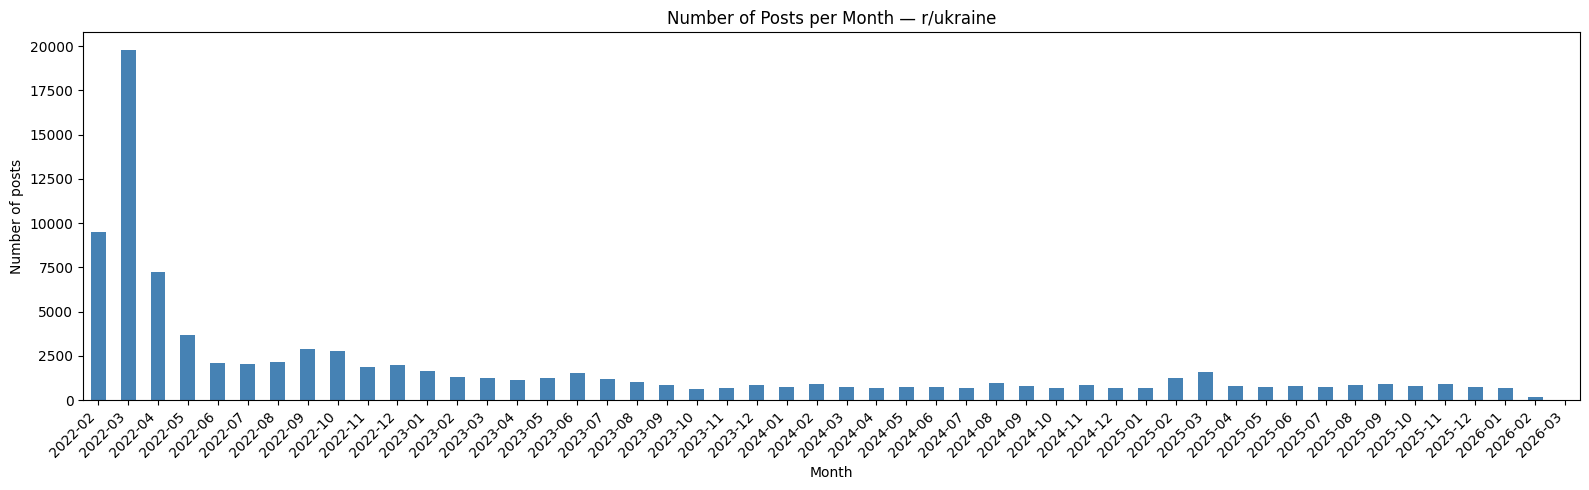

In [31]:
df['year_month'] = df['created_utc'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()

plt.figure(figsize=(16, 5))
monthly_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Posts per Month — r/ukraine')
plt.xlabel('Month')
plt.ylabel('Number of posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df = df.drop(columns=['year_month'])

The chart reveals a clear and expected pattern. Posting activity peaked dramatically in February–April 2022, coinciding with the start of Russia's full-scale invasion of Ukraine on February 24, 2022. March 2022 alone contains over 20,000 posts, which is roughly 10 times more than a typical month in later years.
After this initial surge, activity dropped sharply and stabilized at around 2,000–4,000 posts per month from mid-2022 onward. This is a natural pattern — the community remained active but the extreme spike of the early invasion period gradually normalized.

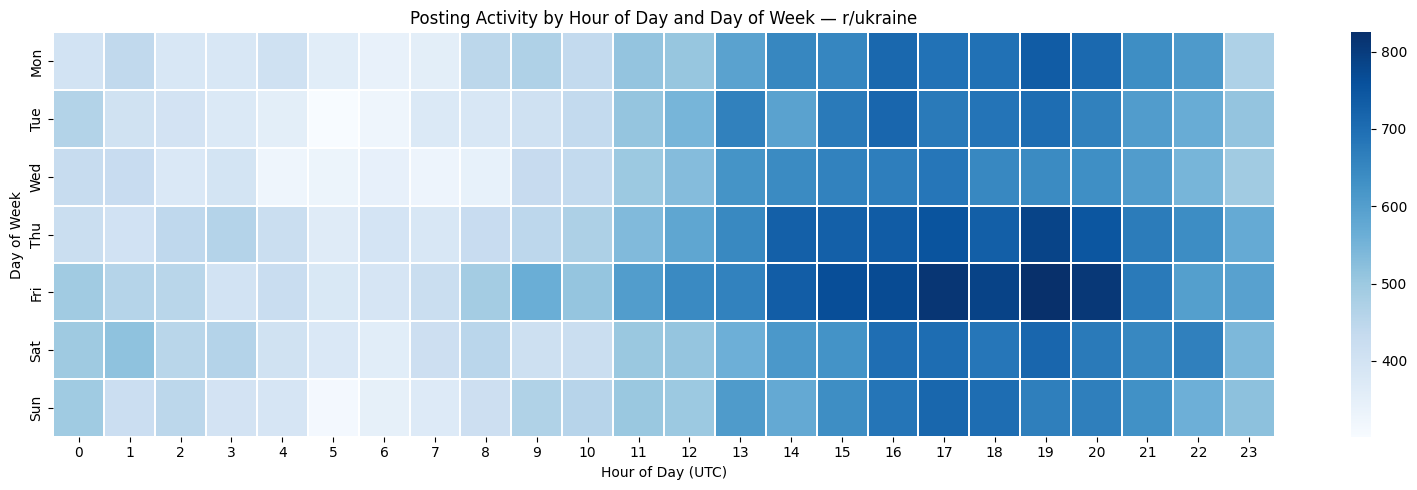

In [32]:
df['hour_of_day'] = df['created_utc'].dt.hour
df['day_of_week'] = df['created_utc'].dt.dayofweek

heatmap_data = df.groupby(['day_of_week', 'hour_of_day']).size().unstack(fill_value=0)
heatmap_data.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.3)
plt.title('Posting Activity by Hour of Day and Day of Week — r/ukraine')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

df = df.drop(columns=['hour_of_day', 'day_of_week'])

The heatmap shows that posting activity on r/ukraine follows a clear daily pattern. Activity is lowest in the early morning hours (0–6 UTC) across all days of the week, and picks up significantly from 10–11 UTC onward. Peak activity consistently falls between 14–20 UTC, which corresponds to afternoon and evening hours in Central European Time — when both Ukrainian and Western European audiences are most active. Weekdays show slightly higher engagement than weekends, with Thursday and Friday appearing particularly active during peak hours.

#### 3.2. Posts distribution by flair

Now we look at how posts are categorized by flair. This helps us understand what topics dominate the subreddit and decide which flairs are relevant for our analysis.

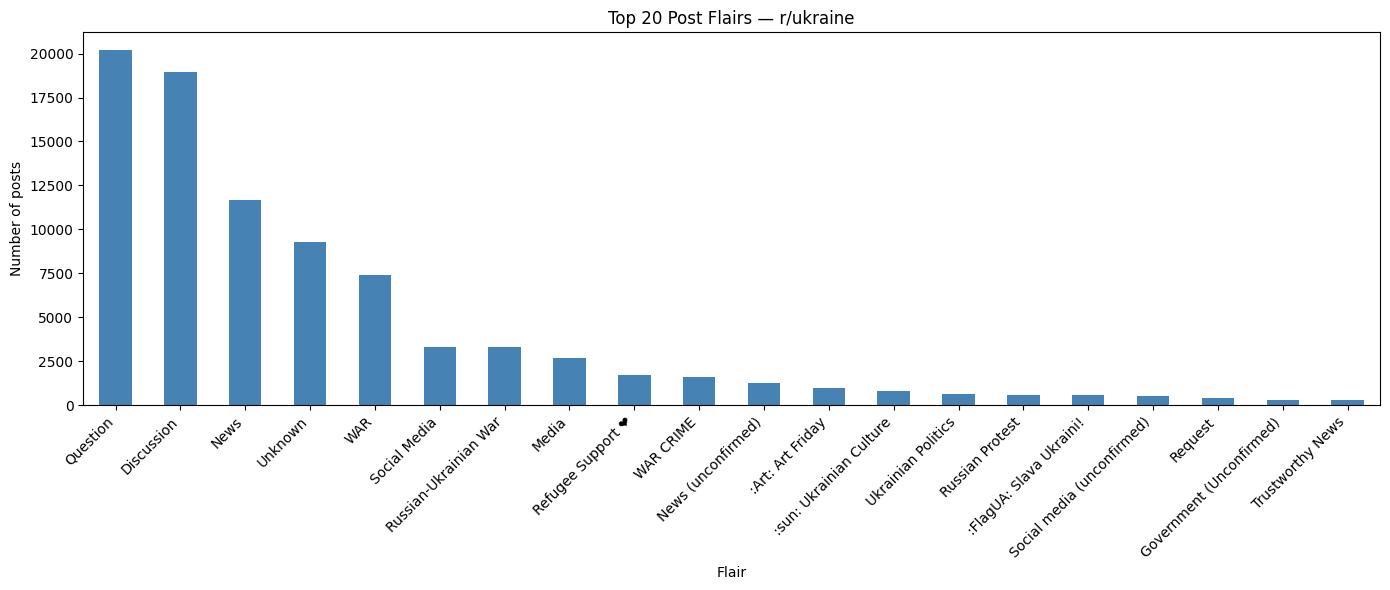

link_flair_text
Question                      20198
Discussion                    18959
News                          11669
Unknown                        9281
WAR                            7398
Social Media                   3328
Russian-Ukrainian War          3321
Media                          2680
Refugee Support ❤              1710
WAR CRIME                      1619
News (unconfirmed)             1246
:Art: Art Friday                993
:sun: Ukrainian Culture         801
Ukrainian Politics              641
Russian Protest                 555
:FlagUA: Slava Ukraini!         555
Social media (unconfirmed)      504
Request                         404
Government (Unconfirmed)        312
Trustworthy News                285
Name: count, dtype: int64


In [33]:
flair_counts = df['link_flair_text'].value_counts()

plt.figure(figsize=(14, 6))
flair_counts.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Post Flairs — r/ukraine')
plt.xlabel('Flair')
plt.ylabel('Number of posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(flair_counts.head(20))

The dataset contains 114 unique flairs in total. Rather than reviewing all of them at once, we approached the filtering in three steps.

**Step 1: Remove obviously off-topic flairs**

Some flairs are clearly unrelated to the war based on their name alone — art, culture, and general patriotic content that carries no predictive value for our task.

In [34]:
flairs_to_remove = [
    ':Art: Art Friday',
    ':sun: Ukrainian Culture',
    ':FlagUA: Slava Ukraini!'
]

before = len(df)
df = df[~df['link_flair_text'].isin(flairs_to_remove)]
print(f"Removed {before - len(df)} off-topic posts")
print(f"Dataset shape: {df.shape}")

Removed 2349 off-topic posts
Dataset shape: (87872, 9)


**Step 2: Review ambiguous flairs**

For flairs that are harder to judge by name alone, we sampled a few posts from each to understand what kind of content they actually contain.

In [35]:
flairs_to_check = [
    'Question',
    'Refugee Support ❤',
    'Request',
    'Social Media',
    'Social media (unconfirmed)'
]

for flair in flairs_to_check:
    subset = df[df['link_flair_text'] == flair][['title', 'selftext']]
    print(f"\n{'='*50}")
    print(f"FLAIR: {flair} ({len(subset)} posts)")
    print(f"{'='*50}")
    
    if len(subset) == 0:
        print("No posts found — already removed.")
        continue
    
    sample = subset.sample(min(5, len(subset)), random_state=42)
    for _, row in sample.iterrows():
        print(f"\nTitle: {row['title']}")
        print(f"Text: {str(row['selftext'])[:200]}")


FLAIR: Question (20198 posts)

Title: What IF Moscow is separated from Russia ?
Text: 

Title: Мені 12 років, я проживаю у місті Ірпінь. Коли снаряд прилетів у мій дім, я з годовалим братом був у бомбосховище, моя мама підіймалась за їжою брату. Вона загинула. Задавайте питання
Text: 

Title: What is "Welcome" in ukranian?
Text: The school I'm working at wants to let the ukranian refugees know that they are welcome here, but unfortunately noone of the employees have ukranian roots or are ukranian themself. So if you could hel

Title: What was life like in Ukraine while the USSR was ruling over?
Text: I would like to get some knowledge as to what it was like in Ukraine for Ukrainians before 1991. Basically from the Bolshevik Revolution until the end of the Cold War. Thanks from Ireland 🇮🇪 

Title: How do the people of Crimea feel about the war? Are they apprehensive about attacking their own country or are they as pro-war as the Russian people are?
Text: 

FLAIR: Refugee Support ❤ (171

After reviewing the samples, we made the following decisions:

- **Question** — mostly general questions about Ukrainian culture, politics, and history. Not useful for the model.
- **Refugee Support ❤** — personal stories, charity posts, and logistical information about refugees. No predictive value.
- **Request** — moderator announcements and off-topic calls to action. Removed.
- **Social Media** — low-quality reposts with excessive emojis and no factual content. Removed.
- **Social media (unconfirmed)** — retained, as samples showed real-time reports of military movements and combat activity directly relevant to our task.

In [36]:
flairs_to_remove_2 = [
    'Question',
    'Request',
    'Social Media',
    'Refugee Support ❤',
]

before = len(df)
df = df[~df['link_flair_text'].isin(flairs_to_remove_2)]
print(f"Removed {before - len(df)} posts")
print(f"Dataset shape: {df.shape}")

Removed 25640 posts
Dataset shape: (62232, 9)


**Step 3: Whitelist — keep only relevant flairs**

After the first two steps, the dataset still contained 114 unique flairs, many of which had very few posts and were clearly off-topic — memes, gaming, cooking, holiday events, and similar content. Instead of manually reviewing each one, we switched to a whitelist approach: explicitly defining which flairs are relevant and removing everything else.
The retained flairs cover the core topics relevant to predicting air raid alerts: war events, news, military activity, political developments, and unconfirmed reports.

In [37]:
print(f"Total unique flairs: {df['link_flair_text'].nunique()}")
print(df['link_flair_text'].value_counts().to_string())

Total unique flairs: 112
link_flair_text
Discussion                                                      18959
News                                                            11669
Unknown                                                          9281
WAR                                                              7398
Russian-Ukrainian War                                            3321
Media                                                            2680
WAR CRIME                                                        1619
News (unconfirmed)                                               1246
Ukrainian Politics                                                641
Russian Protest                                                   555
Social media (unconfirmed)                                        504
Government (Unconfirmed)                                          312
Trustworthy News                                                  285
Media (unconfirmed)                              

In [38]:
flairs_to_keep = [
    'Discussion',
    'News',
    'Unknown',
    'WAR',
    'Russian-Ukrainian War',
    'Media',
    'WAR CRIME',
    'News (unconfirmed)',
    'Ukrainian Politics',
    'Russian Protest',
    'Social media (unconfirmed)',
    'Government (Unconfirmed)',
    'Trustworthy News',
    'Media (unconfirmed)',
    'Military',
    'Combat',
    'NSFL',
    'Bavovna :bavnovna:',
    'Important',
    "People's Republic of Kursk:trizub:",
    'War Crimes',
    'Technology & Economy',
    'credible hot take',
    '🇺🇦 Official',
    'Trustworthy Tweet',
    'WAR | Scarecrow',
    'News recap',
    'Politics: Ukraine Aid',
    'Unconfirmed',
    'WAR | estimate',
    'Russian War Crime',
]

before = len(df)
df = df[df['link_flair_text'].isin(flairs_to_keep)]
print(f"Removed {before - len(df)} off-topic posts")
print(f"Dataset shape after whitelist filtering: {df.shape}")

Removed 2486 off-topic posts
Dataset shape after whitelist filtering: (59746, 9)


#### 3.3. Video posts analysis

We check how many posts contain video content. As discussed earlier, video posts may indicate more verifiable events, so it is useful to understand their share in the dataset.


is_video
False    58371
True      1375
Name: count, dtype: int64

Video posts: 1375 (2.3%)
Non-video posts: 58371 (97.7%)


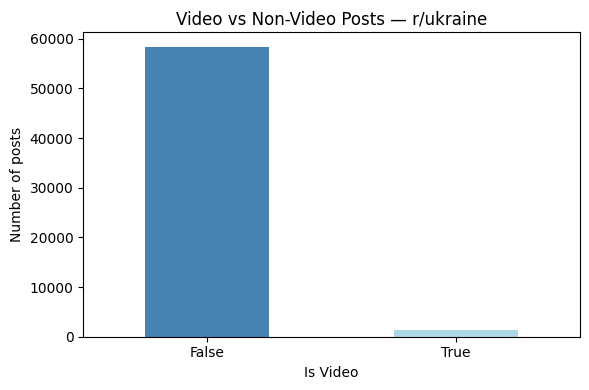

In [39]:
video_counts = df['is_video'].value_counts()
print(video_counts)
print(f"\nVideo posts: {video_counts.get(True, 0)} ({video_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"Non-video posts: {video_counts.get(False, 0)} ({video_counts.get(False, 0)/len(df)*100:.1f}%)")

plt.figure(figsize=(6, 4))
video_counts.plot(kind='bar', color=['steelblue', 'lightblue'])
plt.title('Video vs Non-Video Posts — r/ukraine')
plt.xlabel('Is Video')
plt.ylabel('Number of posts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Only 2.2% of posts (1,563 out of 72,539) contain video content. While video posts may indicate more verifiable events, their share is too small to be a strong standalone feature. However, we retain `is_video` as a binary feature for the modeling phase, where it can contribute as a credibility signal.

Although `is_video` is already stored as a boolean, we convert it to a numeric binary format (0/1) to ensure compatibility with machine learning models during the training phase.

In [40]:
df['is_video'] = df['is_video'].astype(int)
print(df['is_video'].value_counts())
print(f"dtype: {df['is_video'].dtype}")

is_video
0    58371
1     1375
Name: count, dtype: int64
dtype: int64


#### 3.4. Engagement statistics

We look at the distribution of score, num_comments, and upvote_ratio to understand typical post engagement and spot any outliers.


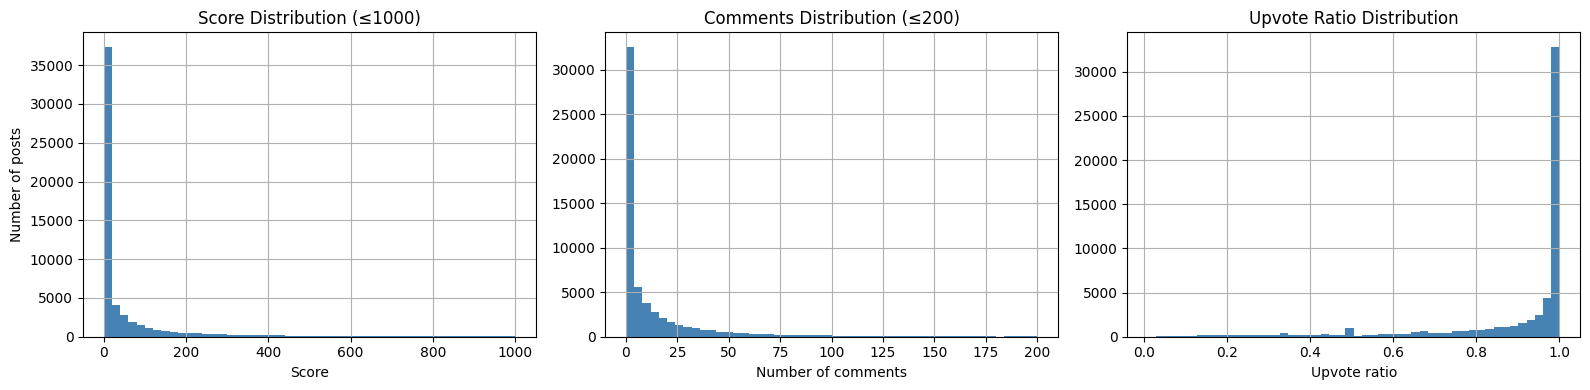

               score  num_comments  upvote_ratio
count   59746.000000  59746.000000  59746.000000
mean      178.004586     19.388695      0.887903
std      1126.990489     66.814404      0.205049
min         0.000000      0.000000      0.010000
25%         1.000000      0.000000      0.880000
50%         1.000000      2.000000      0.990000
75%        66.000000     16.000000      1.000000
max    165784.000000   3328.000000      1.000000


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Score distribution (capped at 1000 for readability)
df[df['score'] <= 1000]['score'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Score Distribution (≤1000)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of posts')

# Number of comments
df[df['num_comments'] <= 200]['num_comments'].hist(bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Comments Distribution (≤200)')
axes[1].set_xlabel('Number of comments')

# Upvote ratio
df['upvote_ratio'].hist(bins=50, ax=axes[2], color='steelblue')
axes[2].set_title('Upvote Ratio Distribution')
axes[2].set_xlabel('Upvote ratio')

plt.tight_layout()
plt.show()

print(df[['score', 'num_comments', 'upvote_ratio']].describe())

All three distributions show a strongly right-skewed pattern, which is typical for social media data:

- **Score** — the median score is just 1, meaning most posts receive very little attention. However, the max reaches 165,784, indicating occasional viral posts. The high standard deviation (1,054) confirms this extreme skew.
- **num_comments** — similarly skewed, with a median of 2 comments and a maximum of 9,159. Most posts generate little discussion, but a small number spark significant engagement.
- **upvote_ratio** — concentrated heavily near 1.0, meaning most posts are well-received by the community with little controversy. The mean of 0.88 confirms this.

These distributions suggest that in the feature engineering phase, we should consider log-transforming `score` and `num_comments` to reduce the impact of extreme outliers on the model.

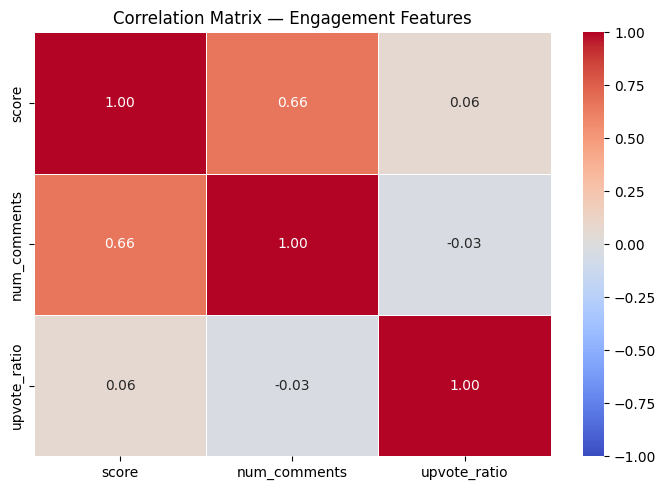

In [42]:
corr_cols = ['score', 'num_comments', 'upvote_ratio']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Engagement Features')
plt.tight_layout()
plt.show()

The correlation matrix reveals that `score` and `num_comments` are moderately positively correlated (0.66), meaning posts that receive more upvotes tend to also generate more discussion. However, `upvote_ratio` is nearly independent of both score (0.06) and num_comments (-0.03), suggesting that community approval is not strongly tied to how much attention a post receives. These three features therefore carry complementary information and are all worth retaining as separate inputs to the model.

#### 3.5. Top authors analysis

We check the most active authors to detect any suspicious accounts that may be bots or spam accounts posting at an unusually high frequency.

author
[deleted]            9205
GermanDronePilot      351
Useful-Scratch-72     248
21_vetal_01           247
CapitalString         197
VR_Bummser            170
Mike-a-b              163
KI_official           159
KharkivOblast         150
vectorix108           146
iceman530             144
OonaMistwalker        137
FNFALC2               136
Chonakz               132
sustainUkraine        130
boskee                124
ua-stena              119
CapKharimwa           117
Snsetoverdi            93
unknown_wtc            92
Name: count, dtype: int64


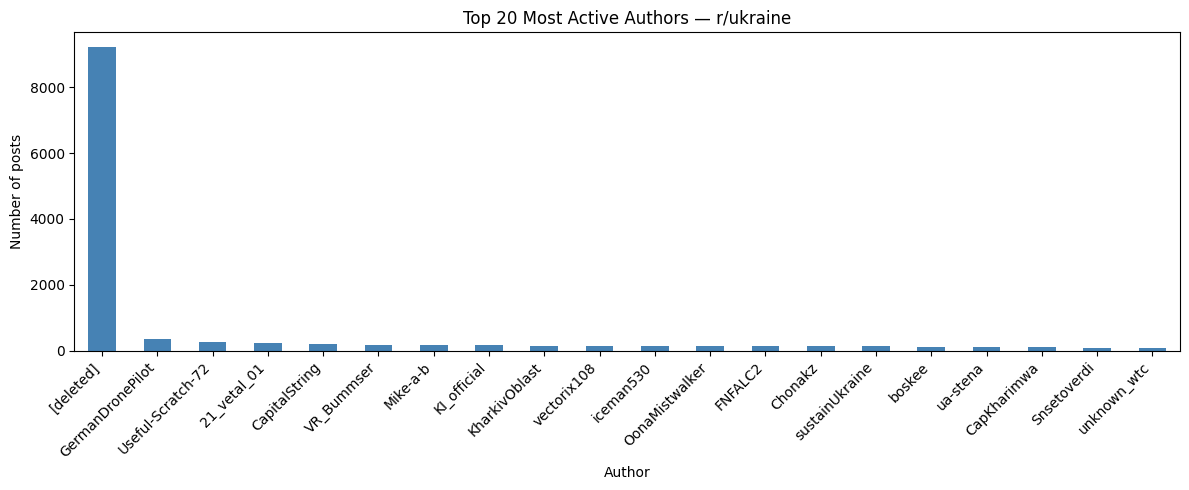

In [43]:
top_authors = df['author'].value_counts().head(20)
print(top_authors)

plt.figure(figsize=(12, 5))
top_authors.plot(kind='bar', color='steelblue')
plt.title('Top 20 Most Active Authors — r/ukraine')
plt.xlabel('Author')
plt.ylabel('Number of posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The most frequent value is `[deleted]` (17,179 posts), which represents all users who deleted their accounts over the 4-year period — this is a single aggregated label, not one account, so these posts are kept.

The remaining top authors posted between 109 and 351 posts in total, which averages to roughly 7–22 posts per month over 4 years. This is consistent with normal human activity for engaged community members. No suspicious bot-like behavior was detected, so no authors were removed. So now we can drop it.

In [44]:
df = df.drop(columns=['author'])
print(f"Dataset shape after dropping author: {df.shape}")

Dataset shape after dropping author: (59746, 8)


#### 3.6. Merging title and selftext

Since both `title` and `selftext` contain textual information relevant to our NLP tasks, we combine them into a single `text` column. This simplifies the pipeline and ensures all available text is used during tokenization and TF-IDF vectorization.

In [45]:
df['text'] = (df['title'] + ' ' + df['selftext']).str.strip()
df = df.drop(columns=['title', 'selftext'])

In [46]:
print(f"Dataset shape after merging text columns: {df.shape}")
df.head()

Dataset shape after merging text columns: (59746, 7)


,created_utc,num_comments,score,upvote_ratio,link_flair_text,is_video,text
4385,2022-02-24 00:04:49+00:00,0,2,1.00,Russian-Ukrainian War,0,The ways to support the Armed Forces of Ukraine
4388,2022-02-24 00:08:05+00:00,3,13,1.00,Unknown,0,UN Security Council to have emergencu meeting ...
4389,2022-02-24 00:08:15+00:00,8,11,1.00,Unknown,0,Airbus A400M-180 Turkish AirForce entered Ukra...
4390,2022-02-24 00:08:50+00:00,0,1,1.00,Russian-Ukrainian War,0,Over/Under on Going All The Way?
4395,2022-02-24 00:16:08+00:00,33,181,0.95,Unknown,0,Short Russian banks and stocks. I trade a mode...


#### Saving the cleaned dataset

After all cleaning and filtering steps, the dataset is ready for the next stage. Below is a summary of the final state before saving.


In [47]:
print(f"Final dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate range: {df['created_utc'].min()} → {df['created_utc'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Final dataset shape: (59746, 7)

Columns: ['created_utc', 'num_comments', 'score', 'upvote_ratio', 'link_flair_text', 'is_video', 'text']

Date range: 2022-02-24 00:04:49+00:00 → 2026-03-02 21:10:30+00:00

Missing values:
created_utc        0
num_comments       0
score              0
upvote_ratio       0
link_flair_text    0
is_video           0
text               0
dtype: int64


,created_utc,num_comments,score,upvote_ratio,link_flair_text,is_video,text
4385,2022-02-24 00:04:49+00:00,0,2,1.00,Russian-Ukrainian War,0,The ways to support the Armed Forces of Ukraine
4388,2022-02-24 00:08:05+00:00,3,13,1.00,Unknown,0,UN Security Council to have emergencu meeting ...
4389,2022-02-24 00:08:15+00:00,8,11,1.00,Unknown,0,Airbus A400M-180 Turkish AirForce entered Ukra...
4390,2022-02-24 00:08:50+00:00,0,1,1.00,Russian-Ukrainian War,0,Over/Under on Going All The Way?
4395,2022-02-24 00:16:08+00:00,33,181,0.95,Unknown,0,Short Russian banks and stocks. I trade a mode...


The cleaned dataset is saved to a CSV file for use in the next stages of the pipeline — feature engineering, NLP processing, and model training.

In [48]:
df.to_csv('reddit_ukraine_final.csv', index=False)
print(f"Saved: {df.shape[0]:,} rows, {df.shape[1]} columns")

Saved: 59,746 rows, 7 columns


## 4. Feature Engineering

#### 4.1. Log-transforming skewed engagement features

As observed in section 3.4, `score` and `num_comments` are heavily right-skewed — most posts receive minimal attention while a few go viral. We apply a log1p transformation (log(1 + x)) to compress this range and reduce the influence of extreme outliers on the model.

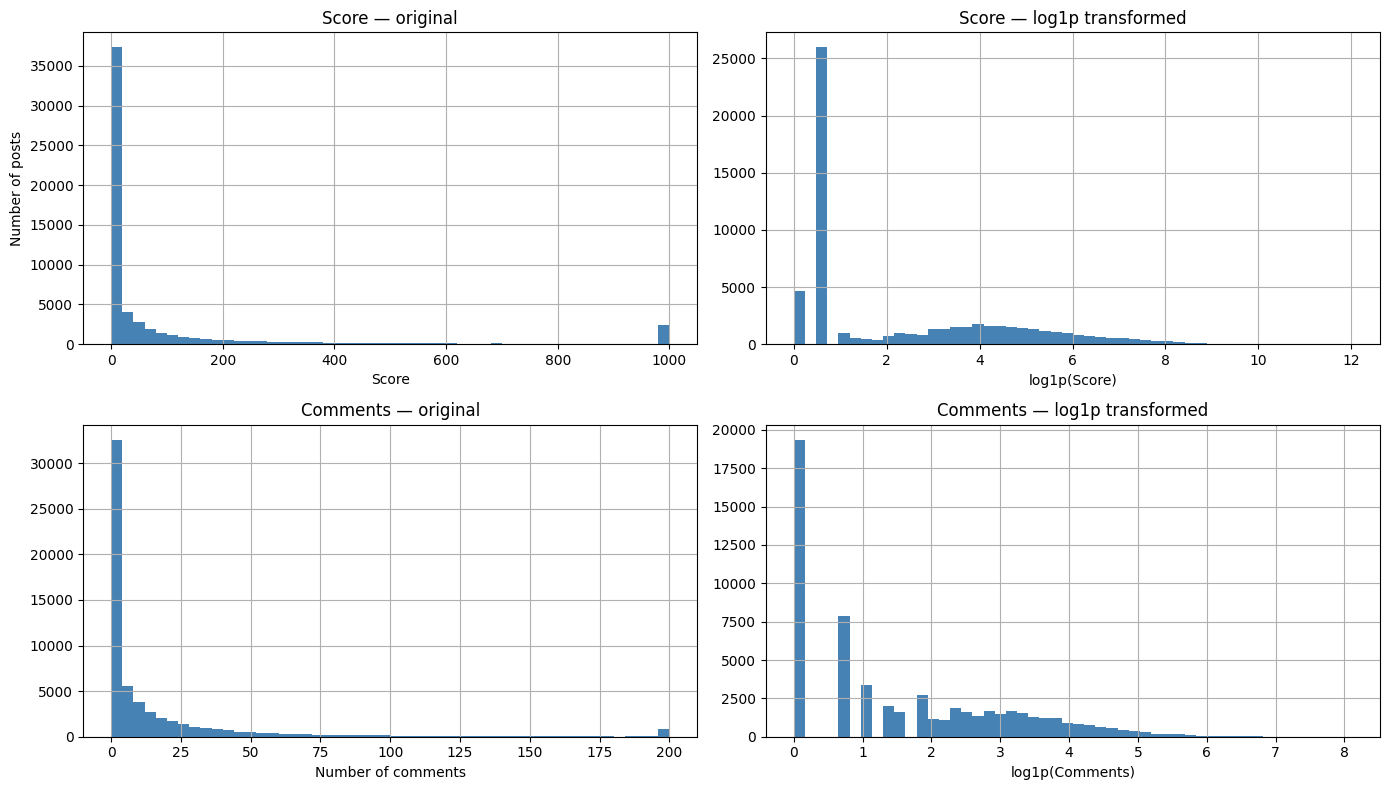

In [49]:
df['score_log'] = np.log1p(df['score'])
df['num_comments_log'] = np.log1p(df['num_comments'])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df['score'].clip(upper=1000).hist(bins=50, ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Score — original')
axes[0][0].set_xlabel('Score')
axes[0][0].set_ylabel('Number of posts')

df['score_log'].hist(bins=50, ax=axes[0][1], color='steelblue')
axes[0][1].set_title('Score — log1p transformed')
axes[0][1].set_xlabel('log1p(Score)')

df['num_comments'].clip(upper=200).hist(bins=50, ax=axes[1][0], color='steelblue')
axes[1][0].set_title('Comments — original')
axes[1][0].set_xlabel('Number of comments')

df['num_comments_log'].hist(bins=50, ax=axes[1][1], color='steelblue')
axes[1][1].set_title('Comments — log1p transformed')
axes[1][1].set_xlabel('log1p(Comments)')

plt.tight_layout()
plt.show()

The log1p transformation reduced the influence of extreme outliers — the long tail visible 
in the original distributions is now compressed. However, both `score` and `num_comments` 
remain zero-inflated: a large share of posts received no upvotes or comments at all, 
which reflects the nature of the r/ukraine community where most posts go unnoticed while 
a few attract significant attention. This skew is expected and acceptable — the transformed 
values will still be more suitable for linear models than the raw counts.

#### 4.2. Flair-based features

Rather than encoding all flair categories individually, we group them into three meaningful 
categories based on their content type:

- **war** — explicitly military or combat-related flairs. Posts in this group may directly 
  correlate with active air raid alerts.
- **unconfirmed** — posts tagged as unconfirmed reports. These often appear before events 
  are officially confirmed, making them useful as early-warning signals.
- **other** — news, discussion, politics, and media posts. Although these may also contain 
  war-related content, the actual text signal will be captured by TF-IDF vectors in step 4.6.

This grouping will be used in the next step to compute hourly ratios for each category.
The original `link_flair_text` column is dropped after encoding.

Total unique flairs: 31

All flairs and their counts:
link_flair_text
Discussion                            18959
News                                  11669
Unknown                                9281
WAR                                    7398
Russian-Ukrainian War                  3321
Media                                  2680
WAR CRIME                              1619
News (unconfirmed)                     1246
Ukrainian Politics                      641
Russian Protest                         555
Social media (unconfirmed)              504
Government (Unconfirmed)                312
Trustworthy News                        285
Media (unconfirmed)                     277
Military                                178
Combat                                  154
Technology & Economy                    110
NSFL                                    105
Bavovna :bavnovna:                      100
Important                                82
People's Republic of Kursk:trizub:       74
War Cr

C:\Users\Мілана\AppData\Local\Temp\ipykernel_6716\2066611658.py:13: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Мілана\AppData\Local\Temp\ipykernel_6716\2066611658.py:13: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Мілана\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Мілана\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


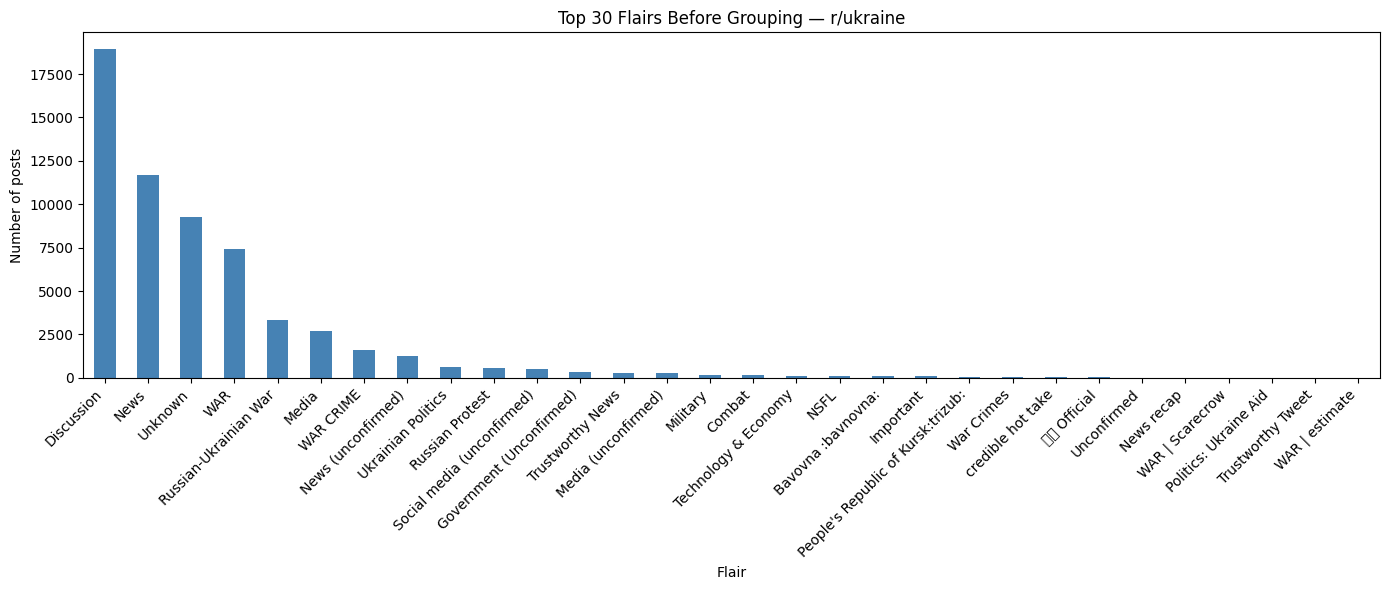

In [50]:
flair_counts = df['link_flair_text'].value_counts()

print(f"Total unique flairs: {df['link_flair_text'].nunique()}")
print(f"\nAll flairs and their counts:")
print(flair_counts.to_string())

plt.figure(figsize=(14, 6))
flair_counts.head(30).plot(kind='bar', color='steelblue')
plt.title('Top 30 Flairs Before Grouping — r/ukraine')
plt.xlabel('Flair')
plt.ylabel('Number of posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [51]:
war_flairs = ['WAR', 'Combat', 'Military', 'WAR CRIME', 'War Crimes',
              'Russian War Crime', 'WAR | Scarecrow', 'WAR | estimate',
              "People's Republic of Kursk:trizub:", 'Bavovna :bavnovna:', 
              'NSFL', 'Russian-Ukrainian War']

unconfirmed_flairs = ['News (unconfirmed)', 'Social media (unconfirmed)',
                      'Government (Unconfirmed)', 'Media (unconfirmed)', 'Unconfirmed']

def assign_flair_group(flair):
    if flair in war_flairs:
        return 'war'
    elif flair in unconfirmed_flairs:
        return 'unconfirmed'
    else:
        return 'other'

df['flair_group'] = df['link_flair_text'].apply(assign_flair_group)
df = df.drop(columns=['link_flair_text'])

print(df['flair_group'].value_counts())
print(f"Dataset shape: {df.shape}")

flair_group
other          44364
war            13033
unconfirmed     2349
Name: count, dtype: int64
Dataset shape: (59746, 9)


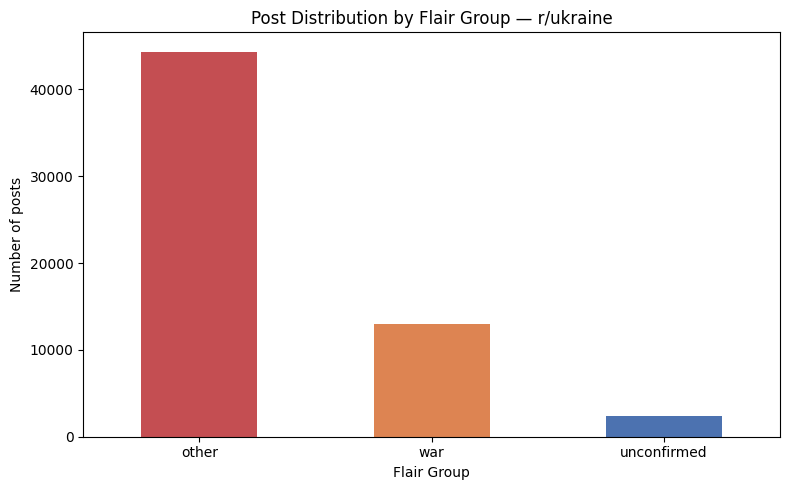

flair_group
other          44364
war            13033
unconfirmed     2349
Name: count, dtype: int64

Shares:
flair_group
other          74.3
war            21.8
unconfirmed     3.9
Name: count, dtype: float64


In [52]:
flair_group_counts = df['flair_group'].value_counts()

plt.figure(figsize=(8, 5))
flair_group_counts.plot(kind='bar', color=['#C44E52', '#DD8452', '#4C72B0'])
plt.title('Post Distribution by Flair Group — r/ukraine')
plt.xlabel('Flair Group')
plt.ylabel('Number of posts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(flair_group_counts)
print(f"\nShares:\n{(flair_group_counts / flair_group_counts.sum() * 100).round(1)}")

After applying the whitelist filtering, the dataset was grouped into three categories. The "other" group (news, discussion, politics, media) dominates with 47,685 posts, while "war" flairs account for roughly 15,000 posts, and "unconfirmed" reports make up the smallest share at around 2,500 posts. This distribution is expected — direct military content and unconfirmed reports are naturally rarer than general news and discussion, but they carry the strongest predictive signal for air raid alerts.

#### 4.3. Hourly aggregation

The core structural transformation of this pipeline: we collapse individual posts into 
hourly time slots. Each row in the resulting dataset represents one hour 
(e.g. 2022-03-01 11:00 UTC) and contains aggregated signals from all posts published 
during that hour.

This step serves two purposes:
1. It aligns the Reddit data with the weather and air raid alarm datasets, which are 
   also structured at hourly granularity.
2. It captures collective community behavior — a spike in post count or engagement 
   within a single hour is a stronger signal than any individual post.

The following features are computed per hour:
- **post_count** — total number of posts (core activity signal)
- **avg_score** — mean engagement score
- **avg_comments** — mean discussion volume
- **avg_upvote_ratio** — community sentiment
- **war_post_ratio** — share of war-flair posts
- **unconfirmed_ratio** — share of unconfirmed reports
- **text** — all post texts concatenated for TF-IDF vectorization in the next step

In [53]:
df['hour_slot'] = df['created_utc'].dt.floor('h')

hourly = df.groupby('hour_slot').agg(
    post_count=('text', 'count'),
    avg_score=('score_log', 'mean'),
    avg_comments=('num_comments_log', 'mean'),
    avg_upvote_ratio=('upvote_ratio', 'mean'),
    war_post_ratio=('flair_group', lambda x: (x == 'war').mean()),
    unconfirmed_ratio=('flair_group', lambda x: (x == 'unconfirmed').mean()),
    text=('text', lambda x: ' '.join(x))
).reset_index()

print(f"Hourly dataset shape: {hourly.shape}")
print(f"Date range: {hourly['hour_slot'].min()} → {hourly['hour_slot'].max()}")
print(f"Expected ~{(hourly['hour_slot'].max() - hourly['hour_slot'].min()).days * 24:,} total hours")
print(f"Hours with at least one post: {len(hourly):,}")
hourly.head()

Hourly dataset shape: (17903, 8)
Date range: 2022-02-24 00:00:00+00:00 → 2026-03-02 21:00:00+00:00
Expected ~35,208 total hours
Hours with at least one post: 17,903


,hour_slot,post_count,avg_score,avg_comments,avg_upvote_ratio,war_post_ratio,unconfirmed_ratio,text
0,2022-02-24 00:00:00+00:00,12,2.335559,1.585556,0.910000,0.416667,0.0,The ways to support the Armed Forces of Ukrain...
1,2022-02-24 01:00:00+00:00,13,3.034745,2.028568,0.789231,0.461538,0.0,Ukraine's national landmarks I won't speculate...
2,2022-02-24 02:00:00+00:00,15,2.816282,1.352396,0.899333,0.066667,0.0,Crimean border now under attack too. [https://...
3,2022-02-24 03:00:00+00:00,80,2.812005,1.293406,0.881875,0.300000,0.0,It is an honor to be a Ukrainian at this hour....
4,2022-02-24 04:00:00+00:00,57,2.152647,1.059120,0.841754,0.456140,0.0,"From the US, I deeply apologize for the curren..."


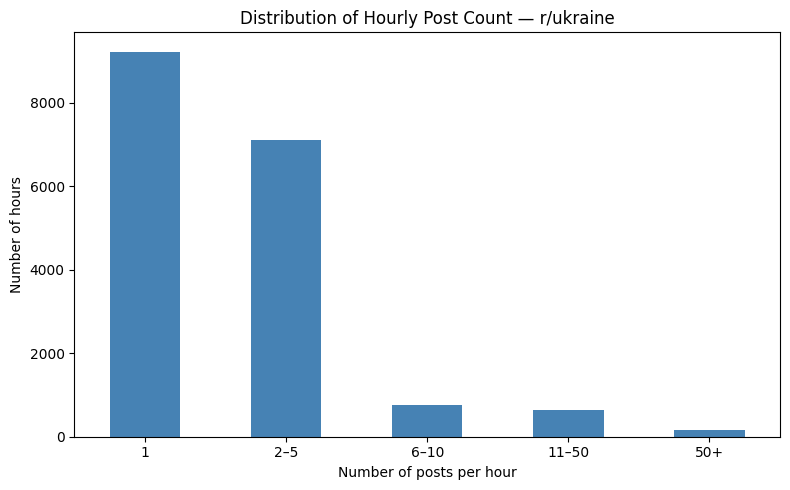

post_count_bin
1        9221
2–5      7109
6–10      771
11–50     650
50+       152
Name: count, dtype: int64

Hours with only 1 post: 9221
Hours with 50+ posts: 155


In [54]:
bins = [0, 1, 5, 10, 50, float('inf')]
labels = ['1', '2–5', '6–10', '11–50', '50+']
hourly['post_count_bin'] = pd.cut(hourly['post_count'], bins=bins, labels=labels)

bin_counts = hourly['post_count_bin'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bin_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Hourly Post Count — r/ukraine')
plt.xlabel('Number of posts per hour')
plt.ylabel('Number of hours')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(bin_counts)
print(f"\nHours with only 1 post: {(hourly['post_count'] == 1).sum()}")
print(f"Hours with 50+ posts: {(hourly['post_count'] >= 50).sum()}")

hourly = hourly.drop(columns=['post_count_bin'])

The vast majority of hourly slots contain very few posts — 9,221 hours have only a single post, and 7,109 hours have between 2 and 5. Only 152 hours recorded 50 or more posts, corresponding to periods of exceptionally high community activity such as the early days of the invasion. This sparse distribution confirms that Reddit activity is highly concentrated around key events, which is exactly the kind of signal that may correlate with air raid alerts.

#### 4.4. Text-based feature extraction

Instead of keeping raw TF-IDF vectors as hundreds of individual columns, we extract
compact numerical features that capture the essence of each hourly slot's text content.
This prevents overfitting and keeps the feature space manageable for merging with other
datasets.

We use three complementary approaches:

**Mention markers (dictionary method)** — custom columns that count the frequency of specific terms directly correlated with air raid alerts. If aviation-related terms spike in a given hour, the probability of alerts increases. Three marker groups are defined: aviation threats, ground activity, and explosions.

**Per-city mention features** — individual binary and count columns for each of the 21 oblast centers (excluding Crimea and Luhansk). Each city has a regex pattern with alternative transliterations to maximise recall across different spelling conventions used on Reddit. A `reddit_geo_unique_cities` aggregate mirrors `isw_geo_unique_locations` from the ISW pipeline, enabling consistent cross-source comparison.

**LDA topic modeling** — Latent Dirichlet Allocation finds hidden thematic structure in the texts. Each hourly slot receives a probability distribution over 5 topics, capturing the general context of community discussion at that time.

Before extracting features, we apply a uniform cleaning pipeline to the concatenated 
hourly text: URLs and numbers are removed, only English letters are kept, text is 
lowercased, and stop words are removed using NLTK.

In [55]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_reddit_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

hourly['text_cleaned'] = hourly['text'].apply(clean_reddit_text)
hourly = hourly.drop(columns=['text'])

print("Sample cleaned text:")
print(hourly['text_cleaned'].iloc[0][:300])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Мілана\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample cleaned text:
ways support armed forces ukraine un security council emergencu meeting kyiv time airbus turkish airforce entered ukrainian airspace going way short russian banks stocks trade moderately large account also mod forex sub post response anything brigade yes short russian stocks short rouble short russi


**1) Mention markers (dictionary method):**

In [56]:
mentions_dict = {
    'reddit_mentions_aviation': [
        'missile', 'shahed', 'drone', 'uav',
        'kinzhal', 'bomber', 'air raid', 'aircraft'
    ],
    'reddit_mentions_ground': [
        'shelling', 'artillery', 'assault',
        'offensive', 'counterattack', 'frontline'
    ],
    'reddit_mentions_explosion': [
        'explosion', 'blast', 'boom', 'strike',
        'hit', 'destroyed', 'burning'
    ]
}


def count_terms(text, terms):
    return sum(1 for term in terms if term in text)

for feature_name, terms in mentions_dict.items():
    hourly[feature_name] = hourly['text_cleaned'].apply(
        lambda x, t=terms: count_terms(x, t)
    )

print(hourly[['hour_slot'] + list(mentions_dict.keys())].head(10))
print(f"\nDataset shape: {hourly.shape}")

                  hour_slot  reddit_mentions_aviation  reddit_mentions_ground  \
0 2022-02-24 00:00:00+00:00                         0                       0   
1 2022-02-24 01:00:00+00:00                         0                       0   
2 2022-02-24 02:00:00+00:00                         2                       0   
3 2022-02-24 03:00:00+00:00                         2                       1   
4 2022-02-24 04:00:00+00:00                         0                       0   
5 2022-02-24 05:00:00+00:00                         0                       0   
6 2022-02-24 06:00:00+00:00                         0                       0   
7 2022-02-24 07:00:00+00:00                         1                       0   
8 2022-02-24 08:00:00+00:00                         0                       0   
9 2022-02-24 09:00:00+00:00                         1                       0   

   reddit_mentions_explosion  
0                          1  
1                          1  
2              

Each hourly slot now has four count-based features reflecting how actively the community 
discussed key topics. A value of 0 means none of the relevant terms appeared in posts 
during that hour. Higher values indicate increased community attention to that topic.

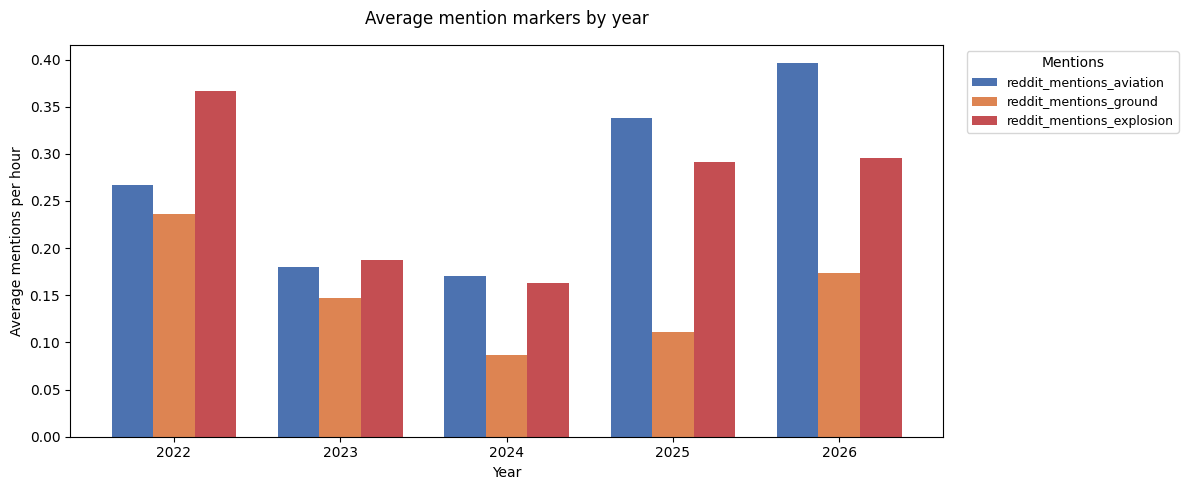

In [57]:
hourly['year'] = hourly['hour_slot'].dt.year

marker_cols = ['reddit_mentions_aviation', 'reddit_mentions_ground',
               'reddit_mentions_explosion']

nice_colors_3 = ['#4C72B0', '#DD8452', '#C44E52']

ax = hourly.groupby('year')[marker_cols].mean().plot(
    kind='bar', 
    figsize=(12, 5), 
    color=nice_colors_3,
    width=0.75
)

plt.title('Average mention markers by year', pad=15)
plt.xlabel('Year')
plt.ylabel('Average mentions per hour')
plt.xticks(rotation=0)

plt.legend(title='Mentions', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\Мілана\AppData\Local\Temp\ipykernel_6716\1339730330.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly['year_month'] = hourly['hour_slot'].dt.to_period('M')


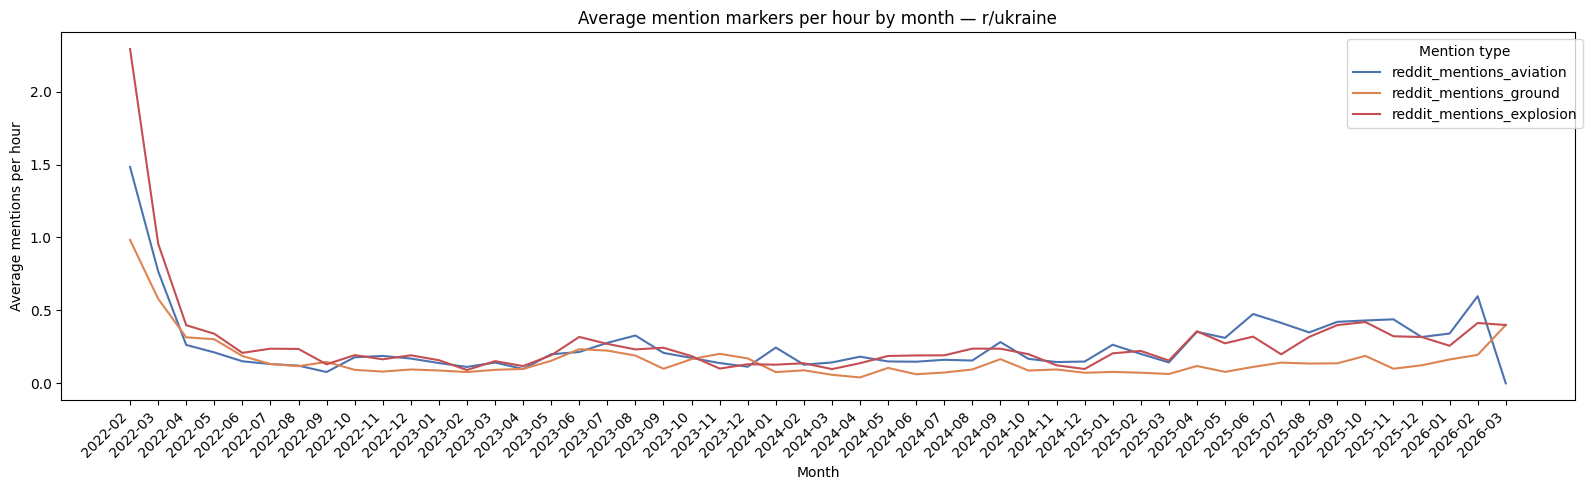

In [58]:
hourly['year_month'] = hourly['hour_slot'].dt.to_period('M')

monthly_mentions = hourly.groupby('year_month')[marker_cols].mean()
monthly_mentions.index = monthly_mentions.index.astype(str)

plt.figure(figsize=(16, 5))
for col, color in zip(marker_cols, nice_colors_3):
    plt.plot(monthly_mentions.index, monthly_mentions[col], label=col, color=color)

plt.title('Average mention markers per hour by month — r/ukraine')
plt.xlabel('Month')
plt.ylabel('Average mentions per hour')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mention type', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

hourly = hourly.drop(columns=['year_month'])

All three mention categories — aviation, ground combat, and explosions — spiked dramatically in February–May 2022, reflecting the intense community focus during the early weeks of the full-scale invasion. After this initial surge, all markers dropped sharply and stabilized at near-zero levels from mid-2022 onward, with only minor fluctuations corresponding to major escalation events. A slight uptick is visible across all categories in early 2026, possibly reflecting renewed escalation during that period.

**2) Per-city mention features**

Instead of a single aggregated `reddit_mentions_cities` score, we extract
individual binary and count features for each of the 21 oblast centers
(excluding Crimea and Luhansk, which are not forecast targets).
 
Each city has a regex pattern with alternative transliterations to maximise
recall — Reddit posts use both modern Ukrainian romanisation (Kharkiv, Odesa)
and older Russian-based spellings (Kharkov, Odessa).
 
For each hourly slot we produce:
- `reddit_{city}_mentioned` — 1 if the city appears at least once that hour
- `reddit_{city}_count`     — total number of term occurrences that hour

In [59]:
city_regex = {
    'Cherkasy':        r'\b(?:cherkasy|cherkassy)\b',
    'Chernihiv':       r'\b(?:chernihiv|chernigov)\b',
    'Chernivtsi':      r'\b(?:chernivtsi|chernovtsy)\b',
    'Dnipro':          r'\b(?:dnipro|dnipropetrovsk)\b',
    'Donetsk':         r'\b(?:donetsk)\b',
    'Ivano-Frankivsk': r'\b(?:ivano frankivsk|ivano-frankivsk)\b',  # clean_reddit_text converts hyphen to space; both variants kept for safety
    'Kharkiv':         r'\b(?:kharkiv|kharkov)\b',
    'Kherson':         r'\b(?:kherson)\b',
    'Khmelnytskyi':    r'\b(?:khmelnytskyi|khmelnitsky)\b',
    'Kropyvnytskyi':   r'\b(?:kropyvnytskyi|kirovohrad)\b',
    'Kyiv':            r'\b(?:kyiv|kiev)\b',
    'Lutsk':           r'\b(?:lutsk|volyn)\b',
    'Lviv':            r'\b(?:lviv|lvov)\b',
    'Mykolaiv':        r'\b(?:mykolaiv|nikolaev)\b',
    'Odesa':           r'\b(?:odesa|odessa)\b',
    'Poltava':         r'\b(?:poltava)\b',
    'Rivne':           r'\b(?:rivne|rovno)\b',
    'Sumy':            r'\b(?:sumy)\b',
    'Ternopil':        r'\b(?:ternopil)\b',
    'Uzhhorod':        r'\b(?:uzhhorod|uzhgorod|zakarpattia)\b',
    'Vinnytsia':       r'\b(?:vinnytsia|vinnitsa)\b',
    'Zaporizhzhia':    r'\b(?:zaporizhzhia|zaporizhia|zaporozhye)\b',
    'Zhytomyr':        r'\b(?:zhytomyr|zhitomir)\b',
}

def count_city_mentions(text, pattern):
    """Count total regex matches for a city pattern in one hourly text block."""
    return len(re.findall(pattern, str(text), flags=re.IGNORECASE))

# col_base: reddit_kyiv, reddit_ivano_frankivsk, etc.
for city, pattern in city_regex.items():
    col_base = 'reddit_' + city.lower().replace('-', '_').replace(' ', '_')
    counts = hourly['text_cleaned'].apply(lambda t, p=pattern: count_city_mentions(t, p))
    hourly[f'{col_base}_count']     = counts           # how many times mentioned
    hourly[f'{col_base}_mentioned'] = (counts > 0).astype(int)  # binary flag

# reddit_geo_unique_cities — mirrors isw_geo_unique_locations from the ISW pipeline
city_mentioned_cols = [c for c in hourly.columns
                       if c.endswith('_mentioned') and c.startswith('reddit_')]
hourly['reddit_geo_unique_cities'] = hourly[city_mentioned_cols].sum(axis=1)

print(f"City columns added: {len(city_mentioned_cols)} binary + {len(city_mentioned_cols)} count")
print(f"Dataset shape: {hourly.shape}")
print("\nSample — top hours by city coverage:")
display(
    hourly[['hour_slot', 'reddit_geo_unique_cities'] + city_mentioned_cols[:5]]
    .sort_values('reddit_geo_unique_cities', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

City columns added: 23 binary + 23 count
Dataset shape: (17903, 59)

Sample — top hours by city coverage:


,hour_slot,reddit_geo_unique_cities,reddit_cherkasy_mentioned,reddit_chernihiv_mentioned,reddit_chernivtsi_mentioned,reddit_dnipro_mentioned,reddit_donetsk_mentioned
0,2024-11-21 07:00:00+00:00,21,1,1,1,1,1
1,2022-02-28 06:00:00+00:00,15,1,1,0,0,1
2,2022-06-04 20:00:00+00:00,13,0,1,0,1,1
3,2022-03-30 05:00:00+00:00,12,1,0,0,1,1
4,2022-02-24 22:00:00+00:00,10,0,1,0,1,1


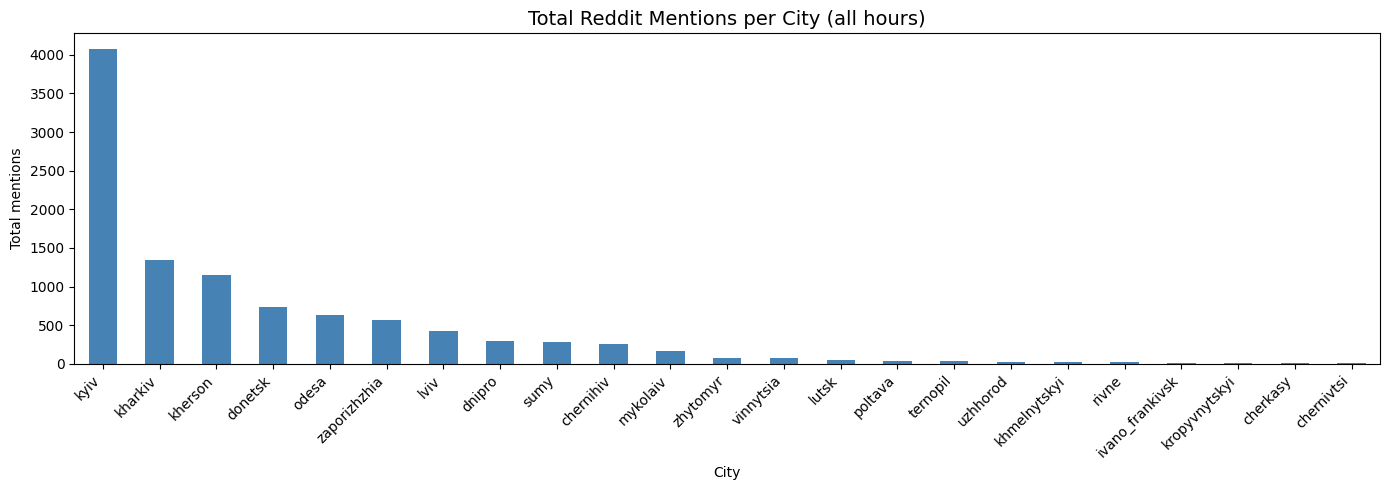

C:\Users\Мілана\AppData\Local\Temp\ipykernel_6716\471538422.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly['year_month'] = hourly['hour_slot'].dt.to_period('M')


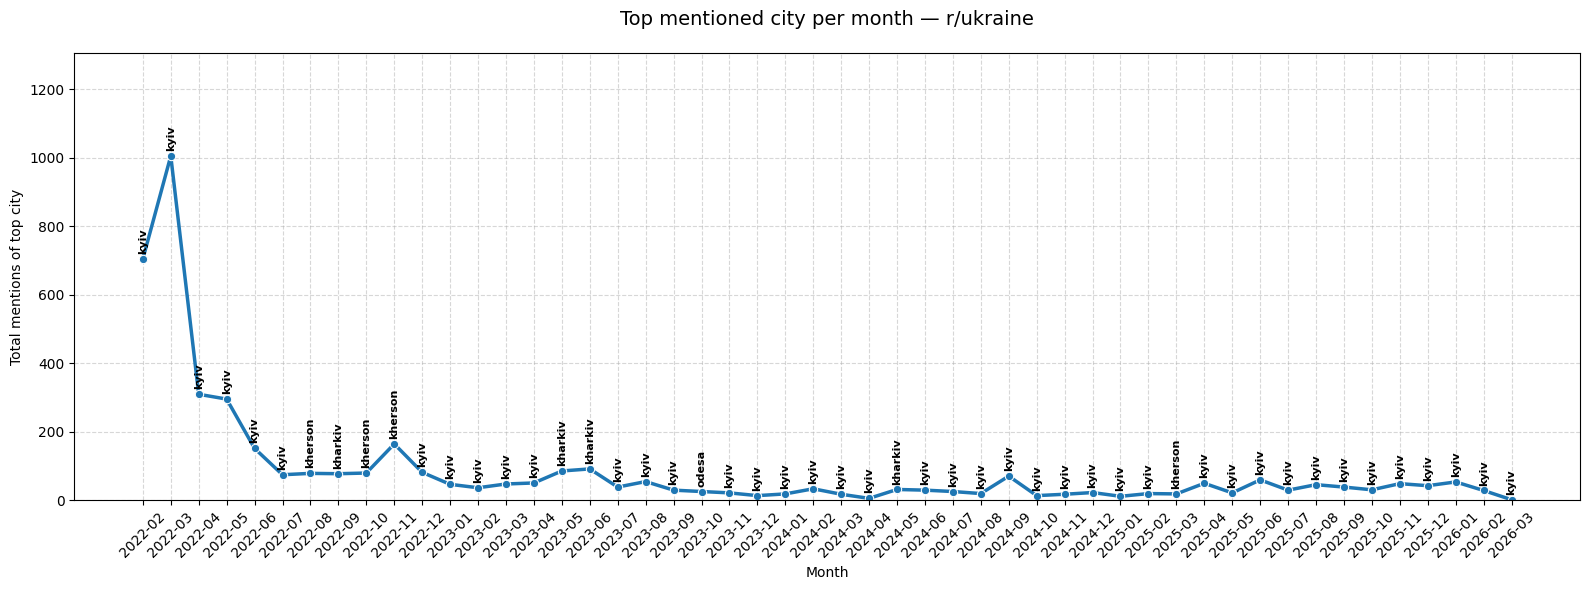


Final dataset shape: (17903, 59)


In [60]:
city_count_cols = [c for c in hourly.columns if c.endswith('_count') and c.startswith('reddit_')]
 
city_totals = hourly[city_count_cols].sum().sort_values(ascending=False)
city_totals.index = [c.replace('reddit_', '').replace('_count', '') for c in city_totals.index]
 
plt.figure(figsize=(14, 5))
city_totals.plot(kind='bar', color='steelblue')
plt.title('Total Reddit Mentions per City (all hours)', fontsize=14)
plt.xlabel('City')
plt.ylabel('Total mentions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
 
hourly['year_month'] = hourly['hour_slot'].dt.to_period('M')
 
records = []
for _, row in hourly.iterrows():
    ym = row['year_month']
    for col in city_count_cols:
        city = col.replace('reddit_', '').replace('_count', '')
        if row[col] > 0:
            records.append({'year_month': ym, 'city': city, 'count': row[col]})
 
df_city_long = pd.DataFrame(records)
monthly_city = df_city_long.groupby(['year_month', 'city'])['count'].sum().reset_index()
top_monthly  = (monthly_city
                .sort_values(['year_month', 'count'], ascending=[True, False])
                .drop_duplicates('year_month'))
 
top_monthly['month_str'] = top_monthly['year_month'].astype(str)
 
plt.figure(figsize=(16, 6))
sns.lineplot(data=top_monthly, x='month_str', y='count', marker='o', linewidth=2.5)
 
max_c = top_monthly['count'].max()
for idx, row in enumerate(top_monthly.itertuples()):
    plt.text(idx, row.count + max_c * 0.02, row.city,
             ha='center', rotation=90, fontsize=8, fontweight='bold')
 
plt.title('Top mentioned city per month — r/ukraine', fontsize=14, pad=20)
plt.xlabel('Month')
plt.ylabel('Total mentions of top city')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, max_c * 1.3)
plt.tight_layout()
plt.show()
 
hourly = hourly.drop(columns=['year_month'])
print(f"\nFinal dataset shape: {hourly.shape}")

Total Reddit Mentions per City (all hours):

- Kyiv dominates with over 4,000 total mentions — roughly three times more than the second most mentioned city, Kharkiv (~1,300). This is expected given Kyiv's role as the capital and the primary target of large-scale missile strikes that drew the most international attention on Reddit. Kharkiv and Kherson follow as the next most discussed cities, reflecting their frontline status throughout the conflict. Cities in western Ukraine (Rivne, Ivano-Frankivsk, Kropyvnytskyi, Cherkasy, Chernivtsi) appear at the bottom of the chart with near-zero mentions, which is consistent with their lower exposure to active hostilities.

Top Mentioned City per Month — r/ukraine:

- The chart tracks which single city accumulated the most mentions each month and how intense that coverage was. The pattern mirrors the dynamics of the war itself: Kyiv peaked sharply in February–March 2022 (~700–1,050 mentions) during the initial assault on the capital, then dropped as Russian forces withdrew from the Kyiv region. From mid-2022 onward Kharkiv and Kherson alternate as the top city, corresponding to the major counteroffensives in those oblasts. After 2023 the monthly peak flattens significantly to under 100 mentions, reflecting both reduced Reddit activity and a shift to a more static frontline. Kyiv resurfaces periodically as the top city during large-scale missile attack waves.

**3) LDA topic modeling:**

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = TfidfVectorizer(
    ngram_range=(2, 2),
    max_features=200,
    min_df=5,
    max_df=0.95
)

tfidf_matrix = vectorizer.fit_transform(hourly['text_cleaned']).toarray()

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    max_iter=10
)

lda_matrix = lda.fit_transform(tfidf_matrix)

print("Top terms per topic:")
for i, topic in enumerate(lda.components_):
    top_terms = [vectorizer.get_feature_names_out()[j] 
                 for j in topic.argsort()[-10:]]
    print(f"Topic {i+1}: {', '.join(top_terms)}")

Top terms per topic:
Topic 1: ukraine war, aid ukraine, ukrainian soldiers, front line, full scale, russia ukraine, air defense, russian forces, slava ukraini, war ukraine
Topic 2: want help, war russia, social media, russian army, pro russian, ukrainian army, russian propaganda, gmail com, help ukraine, ukraine war
Topic 3: russian war, every day, end war, would like, prime minister, removed reddit, russian federation, vladimir putin, russian military, war crimes
Topic 4: glory ukraine, need help, ukrainian forces, long range, russian invasion, gt gt, looks like, russia war, united states, support ukraine
Topic 5: kyiv independent, supporting ukraine, president zelensky, ukrainian military, year old, ukraine russia, black sea, forces ukraine, russian soldiers, armed forces


We apply Latent Dirichlet Allocation on the same TF-IDF matrix to discover hidden 
thematic structure across all hourly slots. We use 5 topics — the model finds them 
automatically based on word co-occurrence patterns.

In [62]:
topic_names = [
    'lda_combat_activity',
    'lda_info_war',
    'lda_politics_crimes', 
    'lda_international_support',
    'lda_official_statements'
]

for i, name in enumerate(topic_names):
    hourly[name] = lda_matrix[:, i]

print(hourly[['hour_slot'] + topic_names].head(10))
print(f"\nDataset shape: {hourly.shape}")

                  hour_slot  lda_combat_activity  lda_info_war  \
0 2022-02-24 00:00:00+00:00             0.054324      0.397647   
1 2022-02-24 01:00:00+00:00             0.351510      0.068733   
2 2022-02-24 02:00:00+00:00             0.063381      0.062606   
3 2022-02-24 03:00:00+00:00             0.047297      0.346582   
4 2022-02-24 04:00:00+00:00             0.414063      0.246757   
5 2022-02-24 05:00:00+00:00             0.293304      0.197200   
6 2022-02-24 06:00:00+00:00             0.045395      0.519422   
7 2022-02-24 07:00:00+00:00             0.155038      0.500474   
8 2022-02-24 08:00:00+00:00             0.048662      0.347746   
9 2022-02-24 09:00:00+00:00             0.133448      0.211579   

   lda_politics_crimes  lda_international_support  lda_official_statements  
0             0.155202                   0.178234                 0.214592  
1             0.441854                   0.069086                 0.068817  
2             0.066997                   0

The five topics identified by LDA map naturally onto distinct aspects of the conflict:

- **Topic 1 (lda_combat_activity)** — dominated by terms related to active frontline 
  fighting: `air defense`, `russian forces`, `front line`. Most directly correlated 
  with air raid alerts.
- **Topic 2 (lda_info_war)** — covers information warfare and propaganda: 
  `russian propaganda`, `pro russian`, `russian army`.
- **Topic 3 (lda_politics_crimes)** — political discourse and war crimes: 
  `vladimir putin`, `war crimes`, `russian federation`.
- **Topic 4 (lda_international_support)** — international aid and weapons supply: 
  `long range`, `united states`, `russian invasion`.
- **Topic 5 (lda_official_statements)** — official communications and naval activity: 
  `black sea`, `armed forces`, `president zelensky`.

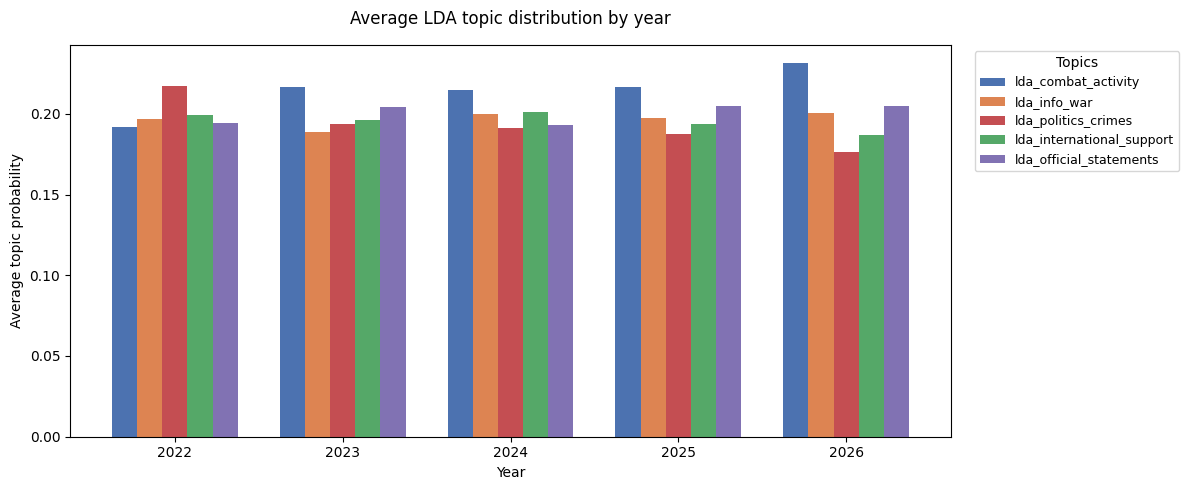

In [63]:
lda_cols = ['lda_combat_activity', 'lda_info_war', 'lda_politics_crimes',
            'lda_international_support', 'lda_official_statements']

nice_colors = ['#4C72B0', '#DD8452', '#C44E52', '#55A868', '#8172B3']

ax = hourly.groupby('year')[lda_cols].mean().plot(
    kind='bar', 
    figsize=(12, 5), 
    color=nice_colors,
    width=0.75
)

plt.title('Average LDA topic distribution by year', pad=15)
plt.xlabel('Year')
plt.ylabel('Average topic probability')
plt.xticks(rotation=0)

plt.legend(title='Topics', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)

plt.tight_layout()
plt.show()

hourly = hourly.drop(columns=['year'])

In [64]:
hourly = hourly.drop(columns=['text_cleaned'])

print(f"Final Reddit feature matrix shape: {hourly.shape}")
print(f"Missing values: {hourly.isnull().sum().sum()}")
display(hourly.head())

Final Reddit feature matrix shape: (17903, 62)
Missing values: 0


,hour_slot,post_count,avg_score,avg_comments,avg_upvote_ratio,war_post_ratio,unconfirmed_ratio,reddit_mentions_aviation,reddit_mentions_ground,reddit_mentions_explosion,...,reddit_zaporizhzhia_count,reddit_zaporizhzhia_mentioned,reddit_zhytomyr_count,reddit_zhytomyr_mentioned,reddit_geo_unique_cities,lda_combat_activity,lda_info_war,lda_politics_crimes,lda_international_support,lda_official_statements
0,2022-02-24 00:00:00+00:00,12,2.335559,1.585556,0.910000,0.416667,0.0,0,0,1,...,0,0,0,0,1,0.054324,0.397647,0.155202,0.178234,0.214592
1,2022-02-24 01:00:00+00:00,13,3.034745,2.028568,0.789231,0.461538,0.0,0,0,1,...,0,0,0,0,0,0.351510,0.068733,0.441854,0.069086,0.068817
2,2022-02-24 02:00:00+00:00,15,2.816282,1.352396,0.899333,0.066667,0.0,2,0,2,...,0,0,0,0,0,0.063381,0.062606,0.066997,0.194102,0.612914
3,2022-02-24 03:00:00+00:00,80,2.812005,1.293406,0.881875,0.300000,0.0,2,1,3,...,0,0,0,0,3,0.047297,0.346582,0.226243,0.161662,0.218216
4,2022-02-24 04:00:00+00:00,57,2.152647,1.059120,0.841754,0.456140,0.0,0,0,3,...,0,0,0,0,5,0.414063,0.246757,0.155530,0.091979,0.091671


Each hourly slot now has a probability distribution over 5 topics. These values sum 
to 1.0 per row — if `lda_combat_activity` is 0.75 for a given hour, it means 75% 
of the community's discussion that hour was focused on active combat. This makes LDA 
values directly interpretable as a measure of community attention to each topic.

To validate the quality of the TF-IDF representation and gain insight into the dominant themes in the dataset, we extract the top 20 bigrams by mean TF-IDF score across all hourly slots. This gives a quick overview of which two-word phrases carry the most consistent signal throughout the entire corpus.

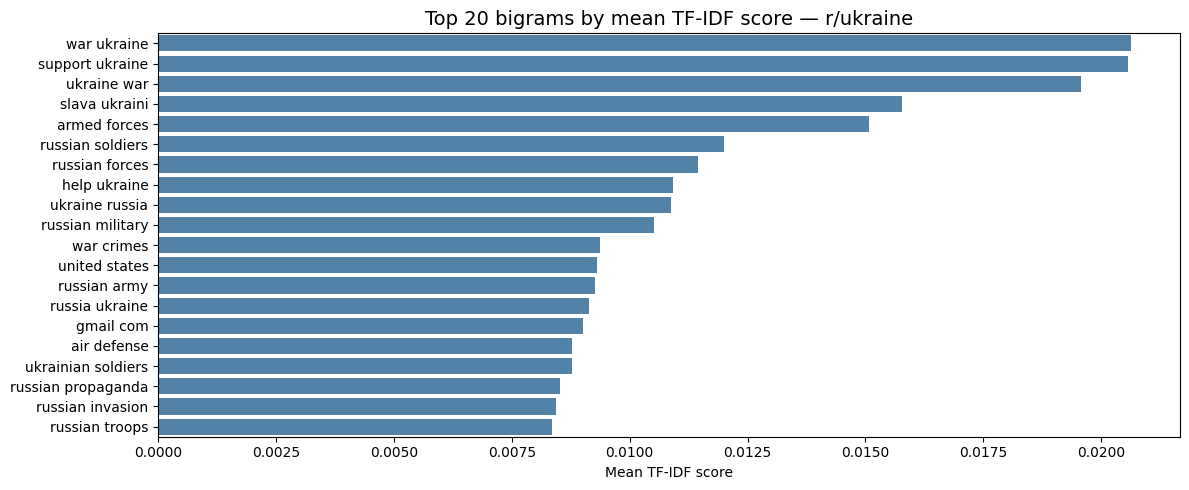

In [65]:
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = tfidf_matrix.mean(axis=0)
top20_idx = mean_tfidf.argsort()[::-1][:20]

top20_bigrams = pd.DataFrame({
    'bigram': feature_names[top20_idx],
    'mean_tfidf': mean_tfidf[top20_idx]
})

plt.figure(figsize=(12, 5))
sns.barplot(data=top20_bigrams, x='mean_tfidf', y='bigram', color='steelblue')
plt.title('Top 20 bigrams by mean TF-IDF score — r/ukraine', fontsize=14)
plt.xlabel('Mean TF-IDF score')
plt.ylabel('')
plt.tight_layout()
plt.show()

The top bigrams confirm that the TF-IDF matrix captured genuinely war-relevant content. The highest-scoring phrases — `war ukraine`, `support ukraine`, `ukraine war` — reflect the core framing of r/ukraine discussions, while repeated military actor variants (`russian soldiers`, `russian forces`, `russian army`) are an expected artifact of TF-IDF on natural language.

One outlier is `gmail com`, likely from volunteer coordination posts — it carries no predictive value and will not affect model quality since TF-IDF scores for such terms are low and inconsistent across hours. `air defense` and `russian invasion` at the bottom are the most task-relevant terms, confirming Reddit as a general discussion signal rather than a specialized source like ISW.

#### 4.5. Feature engineering summary

Below is a summary of all features engineered from the Reddit dataset, grouped by type. 
Each feature represents an aggregated hourly signal ready for merging with weather and 
air raid alarm datasets.

In [66]:
hourly.to_csv('reddit_features_hourly.csv', index=False)
print(f"Saved: {hourly.shape[0]:,} rows, {hourly.shape[1]} columns")
print(f"\nFinal columns: {hourly.columns.tolist()}")

Saved: 17,903 rows, 62 columns

Final columns: ['hour_slot', 'post_count', 'avg_score', 'avg_comments', 'avg_upvote_ratio', 'war_post_ratio', 'unconfirmed_ratio', 'reddit_mentions_aviation', 'reddit_mentions_ground', 'reddit_mentions_explosion', 'reddit_cherkasy_count', 'reddit_cherkasy_mentioned', 'reddit_chernihiv_count', 'reddit_chernihiv_mentioned', 'reddit_chernivtsi_count', 'reddit_chernivtsi_mentioned', 'reddit_dnipro_count', 'reddit_dnipro_mentioned', 'reddit_donetsk_count', 'reddit_donetsk_mentioned', 'reddit_ivano_frankivsk_count', 'reddit_ivano_frankivsk_mentioned', 'reddit_kharkiv_count', 'reddit_kharkiv_mentioned', 'reddit_kherson_count', 'reddit_kherson_mentioned', 'reddit_khmelnytskyi_count', 'reddit_khmelnytskyi_mentioned', 'reddit_kropyvnytskyi_count', 'reddit_kropyvnytskyi_mentioned', 'reddit_kyiv_count', 'reddit_kyiv_mentioned', 'reddit_lutsk_count', 'reddit_lutsk_mentioned', 'reddit_lviv_count', 'reddit_lviv_mentioned', 'reddit_mykolaiv_count', 'reddit_mykolaiv_ment

In [67]:
hourly.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17903 entries, 0 to 17902
Data columns (total 62 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   hour_slot                         17903 non-null  datetime64[ns, UTC]
 1   post_count                        17903 non-null  int64              
 2   avg_score                         17903 non-null  float64            
 3   avg_comments                      17903 non-null  float64            
 4   avg_upvote_ratio                  17903 non-null  float64            
 5   war_post_ratio                    17903 non-null  float64            
 6   unconfirmed_ratio                 17903 non-null  float64            
 7   reddit_mentions_aviation          17903 non-null  int64              
 8   reddit_mentions_ground            17903 non-null  int64              
 9   reddit_mentions_explosion         17903 non-null  int64      

In [68]:
hourly.head()

,hour_slot,post_count,avg_score,avg_comments,avg_upvote_ratio,war_post_ratio,unconfirmed_ratio,reddit_mentions_aviation,reddit_mentions_ground,reddit_mentions_explosion,...,reddit_zaporizhzhia_count,reddit_zaporizhzhia_mentioned,reddit_zhytomyr_count,reddit_zhytomyr_mentioned,reddit_geo_unique_cities,lda_combat_activity,lda_info_war,lda_politics_crimes,lda_international_support,lda_official_statements
0,2022-02-24 00:00:00+00:00,12,2.335559,1.585556,0.910000,0.416667,0.0,0,0,1,...,0,0,0,0,1,0.054324,0.397647,0.155202,0.178234,0.214592
1,2022-02-24 01:00:00+00:00,13,3.034745,2.028568,0.789231,0.461538,0.0,0,0,1,...,0,0,0,0,0,0.351510,0.068733,0.441854,0.069086,0.068817
2,2022-02-24 02:00:00+00:00,15,2.816282,1.352396,0.899333,0.066667,0.0,2,0,2,...,0,0,0,0,0,0.063381,0.062606,0.066997,0.194102,0.612914
3,2022-02-24 03:00:00+00:00,80,2.812005,1.293406,0.881875,0.300000,0.0,2,1,3,...,0,0,0,0,3,0.047297,0.346582,0.226243,0.161662,0.218216
4,2022-02-24 04:00:00+00:00,57,2.152647,1.059120,0.841754,0.456140,0.0,0,0,3,...,0,0,0,0,5,0.414063,0.246757,0.155530,0.091979,0.091671


In [69]:
print(hourly['hour_slot'].dtype)

datetime64[ns, UTC]


## 5. Pipeline summary

The Reddit dataset has been transformed from 100+ raw columns 
into a compact 19-feature hourly matrix ready for modeling.

The pipeline covered four stages:

**Data collection and scope** — posts from r/ukraine from 
February 24, 2022 onward, filtered to war-relevant flairs only.

**Cleaning** — removed stickied posts, late-edited posts, 
media-only posts, duplicates, and off-topic flairs. 
Retained deleted-author posts since the post content itself 
remains intact and carries predictive value.

**Hourly aggregation** — collapsed individual posts into 
hourly time slots to align with air raid and weather datasets. 
Each slot captures collective community behavior rather than 
individual post signals.

**Feature extraction** —  engagement metrics (log-transformed), flair-based ratios, keyword mention counters, per-city binary and count features for 23 oblast centers, a geo coverage aggregate, and LDA topic probabilities. Together they cover five complementary signal types: volume, tone, vocabulary, geography, and theme.

The output file `reddit_features_hourly.csv` is ready 
for merging with other datasets.